In [1]:
import os, torch, torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from PIL import Image
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt
from tqdm import tqdm
import pandas as pd
import numpy as np

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [2]:
BASE       = "/home/fateennr/Codes/ML_Shikhbo/ml-project-swe/plant-village/processed"
train_path = os.path.join(BASE, "train")
val_path   = os.path.join(BASE, "val")
test_path  = os.path.join(BASE, "test")

classes      = sorted([c for c in os.listdir(train_path)
                       if os.path.isdir(os.path.join(train_path, c))])
class_to_idx = {c: i for i, c in enumerate(classes)}
num_classes  = len(classes)

print(f"Total classes: {num_classes}")
print(classes)


Total classes: 6
['Bacterial Spot', 'Early Blight', 'Healthy', 'Late Blight', 'Septoria Leaf Spot', 'Yellow Leaf Curl Virus']


In [3]:
class PlantDataset(Dataset):
    def __init__(self, root, transform=None):
        self.samples = []
        for cls in classes:
            cls_dir = os.path.join(root, cls)
            if not os.path.isdir(cls_dir): continue
            for f in os.listdir(cls_dir):
                if f.endswith(('.png', '.jpg', '.jpeg')):
                    self.samples.append((os.path.join(cls_dir, f), class_to_idx[cls]))
        self.transform = transform

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img = Image.open(path).convert('RGB')
        if self.transform:
            img = self.transform(img)
        return img, label


In [4]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std =[0.229, 0.224, 0.225]
    ),
])

train_ds = PlantDataset(train_path, transform)
val_ds   = PlantDataset(val_path,   transform)
test_ds  = PlantDataset(test_path,  transform)

BATCH_SIZE   = 32
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print(f"Train: {len(train_ds)} | Val: {len(val_ds)} | Test: {len(test_ds)}")


Train: 22218 | Val: 1389 | Test: 1389


In [5]:
model = models.densenet121(weights='IMAGENET1K_V1')

# Replace the last layer to match our 27 disease classes
model.classifier = nn.Sequential(
    nn.Dropout(p=0.3),
    nn.Linear(model.classifier.in_features, num_classes)
)

model = model.to(device)
print(model.classifier)   # confirm the new head


Sequential(
  (0): Dropout(p=0.3, inplace=False)
  (1): Linear(in_features=1024, out_features=6, bias=True)
)


In [6]:
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)  # label smoothing reduces overconfidence
optimizer = optim.AdamW(model.parameters(), lr=3e-5, weight_decay=1e-3)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=20, eta_min=1e-6)

# ── Early Stopping ────────────────────────────────────────────────────────
class EarlyStopping:
    def __init__(self, patience=6, min_delta=0.001):
        self.patience   = patience
        self.min_delta  = min_delta
        self.counter    = 0
        self.best_acc   = 0

    def __call__(self, val_acc):
        if val_acc > self.best_acc + self.min_delta:
            self.best_acc = val_acc
            self.counter  = 0
            return False   # don't stop
        else:
            self.counter += 1
            print(f"  ⏳ EarlyStopping counter: {self.counter}/{self.patience}")
            return self.counter >= self.patience  # True = stop

early_stop = EarlyStopping(patience=6)

print("Loss / Optimizer / Scheduler / EarlyStopping ready")
print(f"   lr            : {optimizer.param_groups[0]['lr']}")
print(f"   weight_decay  : {optimizer.param_groups[0]['weight_decay']}")
print(f"   label_smoothing: 0.1")


Loss / Optimizer / Scheduler / EarlyStopping ready
   lr            : 3e-05
   weight_decay  : 0.001
   label_smoothing: 0.1


In [7]:
def train_one_epoch(model, loader):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for imgs, labels in tqdm(loader, desc="Training", leave=False):
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss    = criterion(outputs, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)  # gradient clipping
        optimizer.step()
        total_loss += loss.item() * imgs.size(0)
        correct    += (outputs.argmax(1) == labels).sum().item()
        total      += imgs.size(0)
    return total_loss / total, correct / total


def evaluate(model, loader):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    with torch.no_grad():
        for imgs, labels in tqdm(loader, desc="Evaluating", leave=False):
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            loss    = criterion(outputs, labels)
            total_loss += loss.item() * imgs.size(0)
            correct    += (outputs.argmax(1) == labels).sum().item()
            total      += imgs.size(0)
    return total_loss / total, correct / total


In [11]:
EPOCHS       = 30
best_val_acc = 0
save_path    = 'densenet121_best.pth'
ckpt_path    = 'densenet121_checkpoint.pth'
history      = {'train_loss':[], 'val_loss':[], 'train_acc':[], 'val_acc':[]}

# ── Auto-resume if checkpoint exists ─────────────────────────────────────
start_epoch = 1
if os.path.exists(ckpt_path):
    checkpoint   = torch.load(ckpt_path, map_location=device)
    model.load_state_dict(checkpoint['model_state'])
    optimizer.load_state_dict(checkpoint['optimizer_state'])
    scheduler.load_state_dict(checkpoint['scheduler_state'])
    start_epoch  = checkpoint['epoch'] + 1
    best_val_acc = checkpoint['best_val_acc']
    history      = checkpoint['history']
    early_stop.best_acc = best_val_acc
    print(f"Resumed from epoch {checkpoint['epoch']}")
    print(f"   Best val acc so far : {best_val_acc*100:.2f}%")
else:
    print("Starting fresh training")

# ── Training loop ─────────────────────────────────────────────────────────
for epoch in range(start_epoch, EPOCHS + 1):
    tr_loss, tr_acc = train_one_epoch(model, train_loader)
    vl_loss, vl_acc = evaluate(model, val_loader)
    scheduler.step()

    history['train_loss'].append(tr_loss)
    history['val_loss'].append(vl_loss)
    history['train_acc'].append(tr_acc)
    history['val_acc'].append(vl_acc)

    # Save best model
    if vl_acc > best_val_acc:
        best_val_acc = vl_acc
        torch.save(model.state_dict(), save_path)
        print(f" Best model saved → val acc: {vl_acc*100:.2f}%")

    # Save checkpoint every epoch (for resuming)
    torch.save({
        'epoch':           epoch,
        'model_state':     model.state_dict(),
        'optimizer_state': optimizer.state_dict(),
        'scheduler_state': scheduler.state_dict(),
        'best_val_acc':    best_val_acc,
        'history':         history,
    }, ckpt_path)

    print(f"Epoch {epoch:02d}/{EPOCHS} | "
          f"Train Loss: {tr_loss:.4f}  Acc: {tr_acc*100:.2f}% | "
          f"Val Loss: {vl_loss:.4f}  Acc: {vl_acc*100:.2f}% | "
          f"LR: {scheduler.get_last_lr()[0]:.2e}")

    # Early stopping check
    if early_stop(vl_acc):
        print(f"\nEarly stopping triggered at epoch {epoch}")
        print(f"   Val accuracy hasn't improved for {early_stop.patience} epochs")
        break

print(f"\n🏁 Training complete!")
print(f"   Best Validation Accuracy : {best_val_acc*100:.2f}%")


Starting fresh training


 Best model saved → val acc: 98.85%
Epoch 01/30 | Train Loss: 0.4956  Acc: 98.20% | Val Loss: 0.4685  Acc: 98.85% | LR: 2.72e-05


Epoch 02/30 | Train Loss: 0.4738  Acc: 98.98% | Val Loss: 0.4625  Acc: 98.85% | LR: 2.58e-05
  ⏳ EarlyStopping counter: 1/6


 Best model saved → val acc: 99.06%
Epoch 03/30 | Train Loss: 0.4636  Acc: 99.33% | Val Loss: 0.4593  Acc: 99.06% | LR: 2.40e-05


Epoch 04/30 | Train Loss: 0.4555  Acc: 99.51% | Val Loss: 0.4548  Acc: 98.92% | LR: 2.21e-05
  ⏳ EarlyStopping counter: 1/6


Epoch 05/30 | Train Loss: 0.4482  Acc: 99.66% | Val Loss: 0.4581  Acc: 98.63% | LR: 2.00e-05
  ⏳ EarlyStopping counter: 2/6


Epoch 06/30 | Train Loss: 0.4442  Acc: 99.70% | Val Loss: 0.4580  Acc: 98.56% | LR: 1.78e-05
  ⏳ EarlyStopping counter: 3/6


Epoch 07/30 | Train Loss: 0.4417  Acc: 99.72% | Val Loss: 0.4525  Acc: 98.99% | LR: 1.55e-05
  ⏳ EarlyStopping counter: 4/6


Epoch 08/30 | Train Loss: 0.4371  Acc: 99.82% | Val Loss: 0.4538  Acc: 98.56% | LR: 1.32e-05
  ⏳ EarlyStopping counter: 5/6


Epoch 09/30 | Train Loss: 0.4360  Acc: 99.85% | Val Loss: 0.4549  Acc: 98.49% | LR: 1.10e-05
  ⏳ EarlyStopping counter: 6/6

Early stopping triggered at epoch 9
   Val accuracy hasn't improved for 6 epochs

🏁 Training complete!
   Best Validation Accuracy : 99.06%


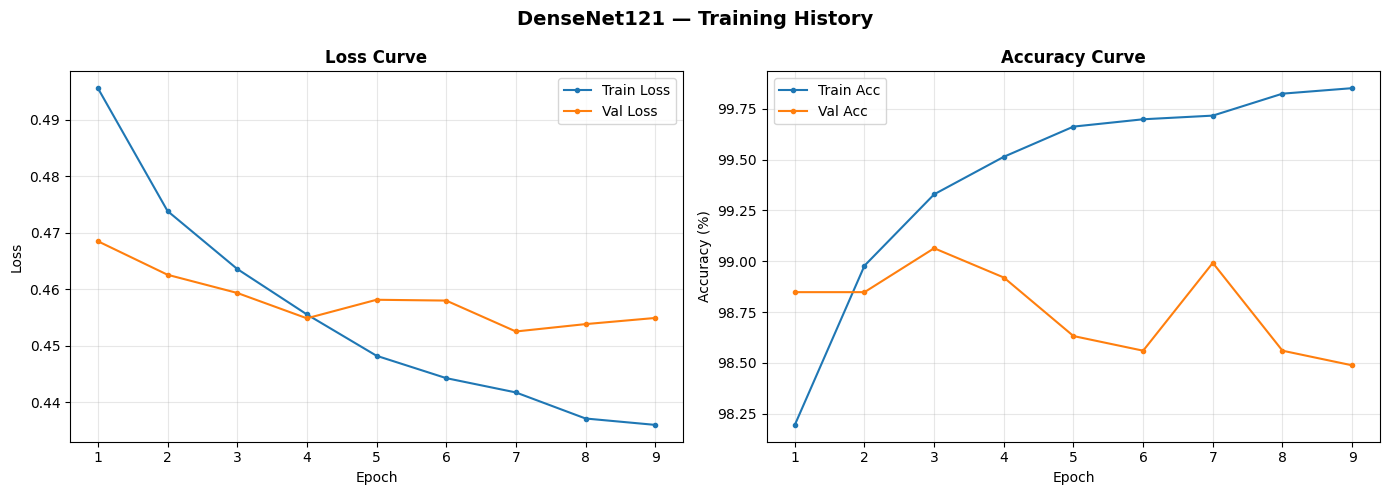

In [16]:
epochs_ran = len(history['train_loss'])
x          = range(1, epochs_ran + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(x, history['train_loss'], label='Train Loss', marker='o', markersize=3)
axes[0].plot(x, history['val_loss'],   label='Val Loss',   marker='o', markersize=3)
axes[0].set_title('Loss Curve', fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(x, [a*100 for a in history['train_acc']], label='Train Acc', marker='o', markersize=3)
axes[1].plot(x, [a*100 for a in history['val_acc']],   label='Val Acc',   marker='o', markersize=3)
axes[1].set_title('Accuracy Curve', fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle('DenseNet121 — Training History', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('training_curves.png', dpi=150)
plt.show()


In [14]:
model.load_state_dict(torch.load(save_path, map_location=device))

all_preds, all_labels_list = [], []
model.eval()
with torch.no_grad():
    for imgs, labels in tqdm(test_loader, desc="Testing"):
        outputs = model(imgs.to(device))
        preds   = outputs.argmax(1).cpu().tolist()
        all_preds.extend(preds)
        all_labels_list.extend(labels.tolist())

test_acc = accuracy_score(all_labels_list, all_preds)
print(f"\n✅ DenseNet121 Test Accuracy: {test_acc*100:.2f}%")
print(f"   Best Val Accuracy        : {best_val_acc*100:.2f}%")

print("\n── Classification Report ──────────────────────")
print(classification_report(all_labels_list, all_preds, target_names=classes))


Testing: 100%|██████████| 44/44 [00:02<00:00, 15.17it/s]


✅ DenseNet121 Test Accuracy: 97.84%
   Best Val Accuracy        : 99.06%

── Classification Report ──────────────────────
                        precision    recall  f1-score   support

        Bacterial Spot       0.97      0.97      0.97       213
          Early Blight       0.95      0.97      0.96       240
               Healthy       1.00      1.00      1.00       241
           Late Blight       0.99      0.95      0.97       231
    Septoria Leaf Spot       0.97      0.97      0.97       219
Yellow Leaf Curl Virus       0.99      1.00      1.00       245

              accuracy                           0.98      1389
             macro avg       0.98      0.98      0.98      1389
          weighted avg       0.98      0.98      0.98      1389



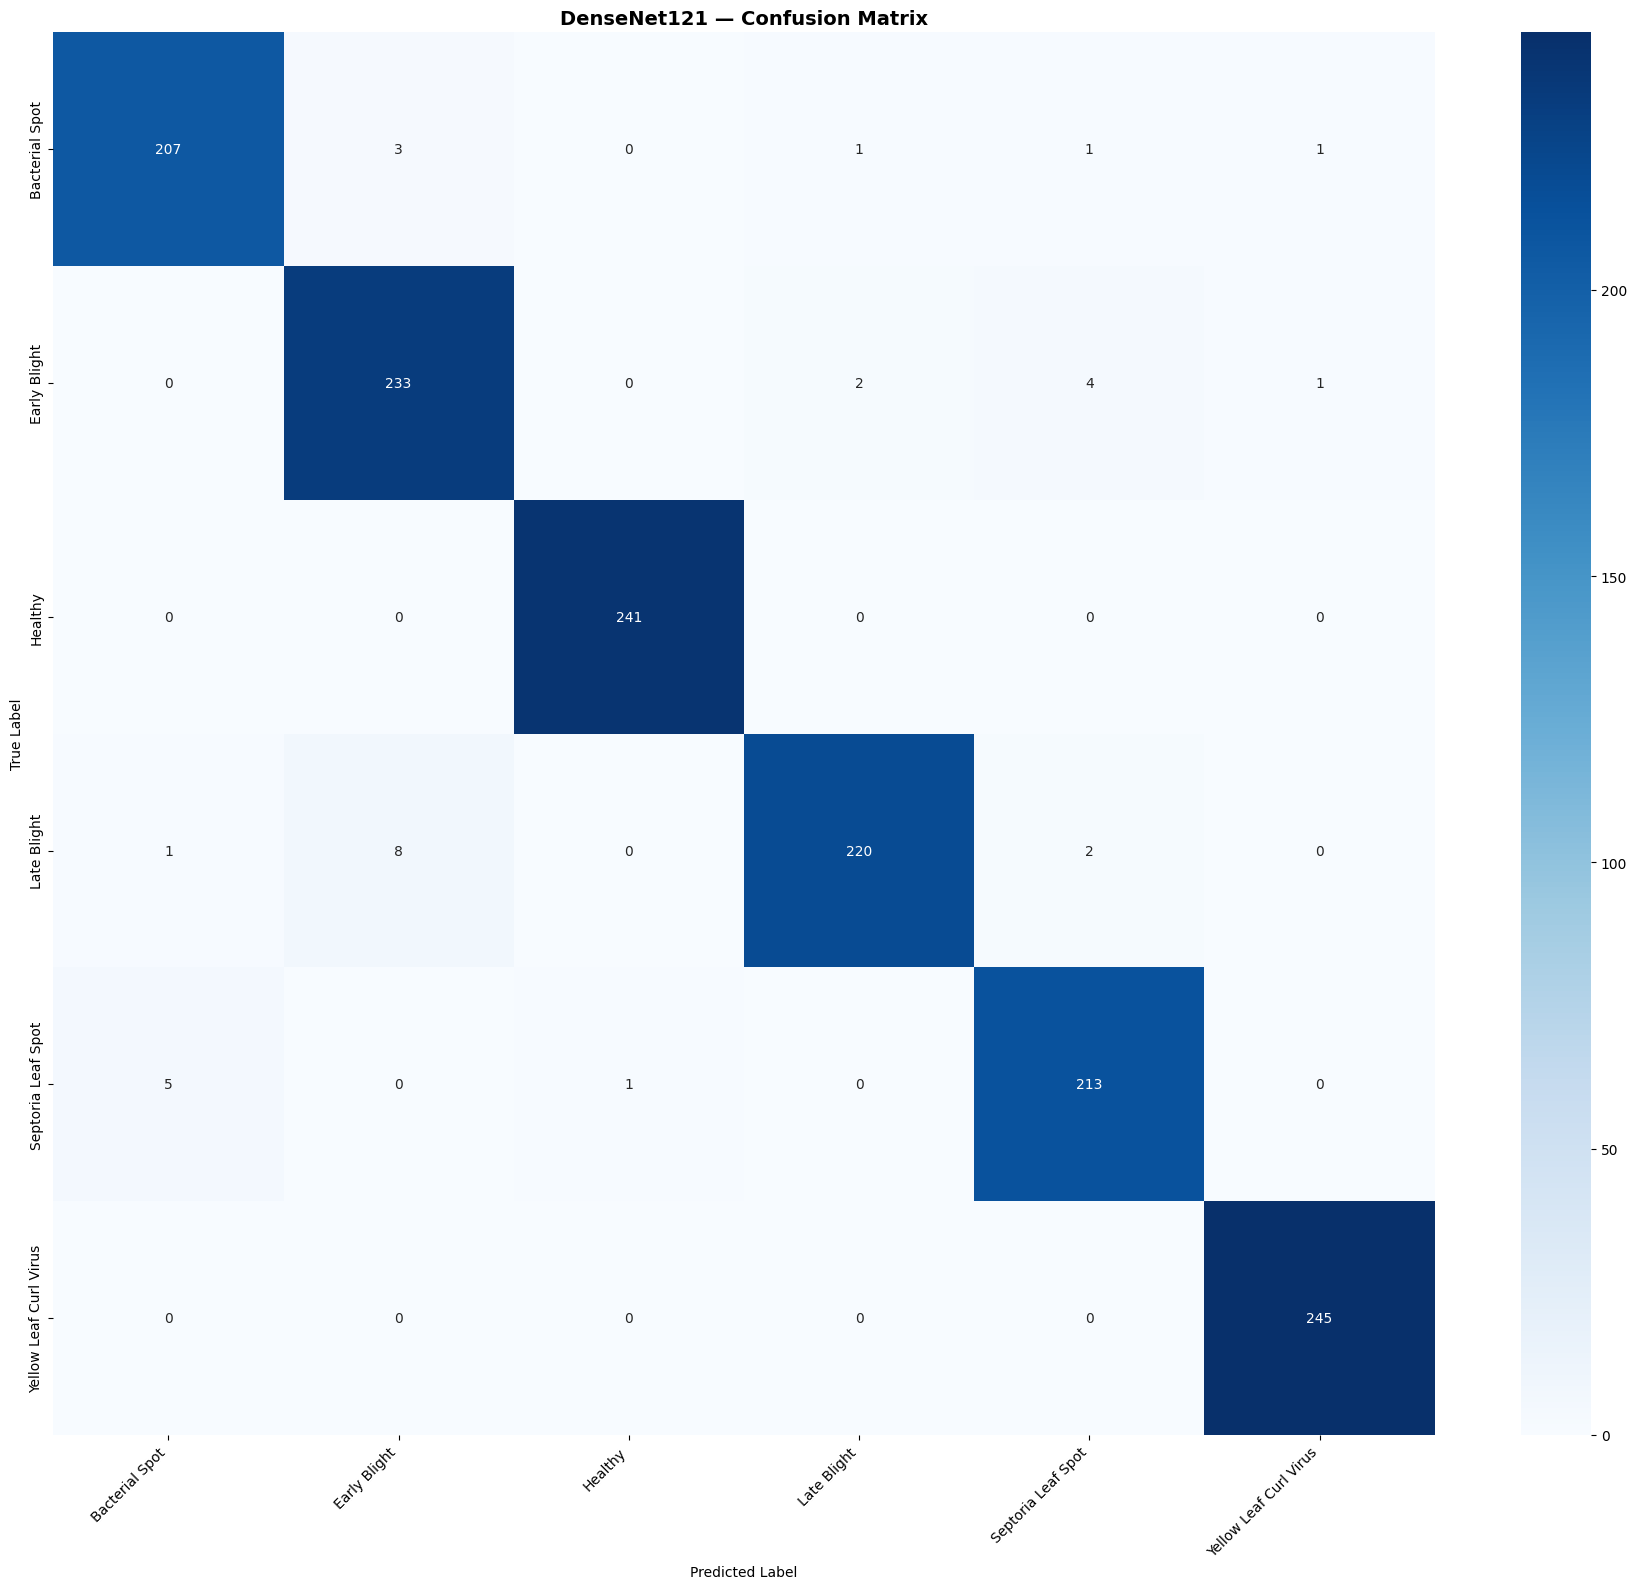

In [18]:
cm = confusion_matrix(all_labels_list, all_preds)

plt.figure(figsize=(18, 16))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=classes,
            yticklabels=classes,
            cmap='Blues')
plt.title('DenseNet121 — Confusion Matrix', fontsize=14, fontweight='bold')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()
